In [1]:
import torch
import numpy as np
import scipy
import pytorch_lightning as pl
from tqdm import tqdm
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
torch.set_float32_matmul_precision('medium')

import multiprocessing
# multiprocessing.set_start_method('spawn')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import os, sys

sys.path.append("../../mist-base")
sys.path.append('../../')

from src.simulators.fd_simulators import GW_Additive_F, GW_Additive_F_Correlated
from simulators.utils import *
from utils.data import OnTheFlyDataModule, StoredDataModule
from utils.module import CustomLossModule_withBounds, BCELossModule, NewLossModule_withBounds
from models.online_norm import OnlineStandardizingLayer
from models.resnet_1d import ResidualNet

import plotfancy as pf

mycolors = ['#570f6d', '#bb3754', '#f98e08']
quantiles = np.array([0.05199686, 0.2145543,  0.58780088, 1.17737921, 1.91882754,
 2.75067576, 3.63463655])

quantiles_long = np.array([7.11978022e-04, 7.96148769e-03, 5.19968566e-02, 2.14554300e-01,
 5.87800876e-01, 1.17737921e+00, 1.91882754e+00, 2.75067576e+00,
 3.63463655e+00, 4.55164698e+00, 5.49045819e+00])

In [2]:
simulator_plot = GW_Additive_F(bkg=True, fraction=0.002)
simulator = GW_Additive_F(bkg=True, fraction=0.2)

Fetching 1000s of data from H1. Will take <4mins.
Calculating PSD for FFT window length 2s.
Fetching 1000s of data from H1. Will take <4mins.
Calculating PSD for FFT window length 2s.


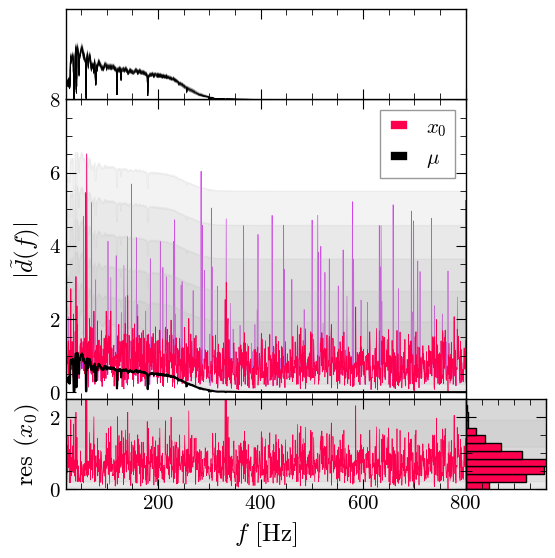

In [3]:
test = simulator_plot.sample(1)

pf.housestyle_rcparams()
fig, ax1 = pf.create_plot()

plt.setp(ax1.get_xticklabels(), visible=False)
ax2 = fig.add_axes((0,-.3,1,0.3), sharex=ax1)
ax3 = fig.add_axes((1,-.3,0.2,0.3), sharey=ax2)
plt.setp(ax3.get_xticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
ax4 = fig.add_axes((0,1,1,0.3), sharex=ax1)
plt.setp(ax4.get_xticklabels(), visible=False)


ax1.plot(simulator.grid,torch.abs(test['x0'][0]), label=r'$x_0$', color='#ff004f', lw=0.5)
ax1.plot(simulator.grid,torch.abs(test['mu'][0]), label=r'$\mu$', color='black')
ax1.set_ylabel(r'$|\tilde{d}(f)|$')
ax1.set_ylim([-.2,8])
ax1.legend(loc='upper right')
ax1.set_xlim(20, 800)


resd = torch.abs(test['x0'][0]-test['mu'][0])
ax2.plot(simulator.grid,resd, color='#ff004f', lw=0.5)
ax2.set_xlabel(r'$f$ [Hz]')
ax2.set_ylabel(r'res ($x_0$)')
ax2.set_ylim([0,2.5])
for i in range(1,6):
    ax1.fill_between(simulator.grid, quantiles_long[i]+torch.abs(test['mu'][0]), quantiles_long[-i]+torch.abs(test['mu'][0]),  color='#b0b0b0', alpha=0.15)
    ax2.fill_between(simulator.grid, quantiles_long[i], quantiles_long[-i],  color='#b0b0b0', alpha=0.15)
    ax3.fill_between(simulator.grid, quantiles_long[i], quantiles_long[-i],  color='#b0b0b0', alpha=0.15)

ax3.hist(resd, orientation='horizontal', bins=torch.linspace(0,3, 15), edgecolor='black', color='#ff004f', density=True)
ax3.set_xlim([0,1])

for i in range(100):
    ax4.plot(simulator.grid,torch.abs(simulator.sample(1)['mu'][0]), lw=0.5, color='black', alpha=0.05)


ax4.set_yticks([])
ax4.set_ylim([0,2])
ax4.set_visible(False if simulator.bkg==False else True)
pf.fix_plot([ax1,ax2, ax3,ax4])

ax1.plot(simulator.grid,torch.abs(test['xi'][0]), label=r'$x_i$', color="#d931f3", lw=0.5, zorder=-1)


In [4]:
class Network_epsilon(torch.nn.Module):
    def __init__(self, nbins):
        super().__init__()
        
        self.nbins = nbins

        self.logvariance = torch.nn.Parameter(torch.ones(self.nbins)*5)

        self.net = ResidualNet(1, 1, hidden_features=128, num_blocks=2, kernel_size=1, padding=0) 
        self.mu_predictor = torch.nn.Sequential(
            torch.nn.Linear(self.nbins, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, self.nbins)
        )

    def mu(self, x):
        x = self.mu_predictor(x.unsqueeze(1)).squeeze(1)
        return x
                
    def epsilon(self, x):
        resd = x - self.mu(x)
        out = self.net(resd.unsqueeze(1)).squeeze(1) # x-net
        return out
    
    def snr(self, x):
        mag = torch.abs(x)
        return self.epsilon(mag) / self.logvariance.exp().sqrt()  # [B, N_bins]
    
    def bounds(self):
        return self.logvariance.detach().exp().sqrt().mean(-1) * 5

        
    def forward(self, x):
        
        x0_block = x['x0']
        mu_block = x['mu']
        ni = x['ni']
        
        ###########################################
        epsilon_sim =  (2 * self.bounds() * torch.rand(x['x0'].shape, 
                                                           device= x['x0'].device, 
                                                           dtype= x['x0'].dtype) - self.bounds()) * ni
        ###########################################

        data = x0_block+epsilon_sim
        
        # net evaluation_m
        net_mu = self.mu(data)
        error_mu = (net_mu-mu_block)**2
        l_mu = error_mu / (self.logvariance.exp() + 1e-10) + self.logvariance
        l_mu_return = l_mu.sum() * 0.5

        # net evaluation_e
        net_epsilon = self.epsilon(data)
        mask = ( ni != 0 )  
        squared_error_e = (net_epsilon - epsilon_sim)**2                                         # [B, N_bins]
        l_e = squared_error_e / (self.logvariance.exp() + 1e-21) + self.logvariance                   # [B, N_bins]
        l_e_return = (l_e * mask.float()).sum() * 0.5
        
        # combine
        return l_mu_return+l_e_return

In [5]:
batch_size = 128

dm = OnTheFlyDataModule(simulator, Nsims_per_epoch=400*batch_size, batch_size=batch_size, num_workers=31)

network_epsilon = Network_epsilon(nbins=simulator.Nbins)
model = NewLossModule_withBounds(network_epsilon, learning_rate=3e-3)
trainer = pl.Trainer(
    accelerator="gpu", 
    max_epochs=50, 
    precision=64,
    # fast_dev_run=True
)
trainer.fit(model, dm)
network_epsilon.cuda().eval();

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type            | Params | Mode 
--------------------------------------------------
0 | model | Network_epsilon | 1.1 M  | train
--------------------------------------------------
1.1 M     Trainable params
0         Non-trainable params
1.1 M     Total params
4.560     Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/ioa/software/anaconda3/envs/python-3.11-2023-12a/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/opt/ioa/software/anaconda3/envs/python-3.11-2023-12a/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


RuntimeError: mat1 and mat2 must have the same dtype, but got ComplexDouble and Double